In [32]:
import os

from contextlib import contextmanager

import psycopg2
from psycopg2.extras import execute_values

import pandas as pd
from sqlalchemy import create_engine

import numpy as np

from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score, roc_curve, auc
from sklearn.metrics import precision_recall_curve, average_precision_score

from sklearn.ensemble import RandomForestClassifier

import matplotlib.pyplot as plt
import seaborn as sns

In [33]:
DB_CONFIG = {
    "host": "127.0.0.1",
    "port": 5433,          
    "dbname": "cardio_db", 
    "user": "postgres",
    "password": "admin123"
}

In [34]:
db_uri = f"postgresql://{DB_CONFIG['user']}:{DB_CONFIG['password']}@{DB_CONFIG['host']}:{DB_CONFIG['port']}/{DB_CONFIG['dbname']}"

engine = create_engine(db_uri)

patients_cleaned = "SELECT * FROM patients_cleaned"

try:
    df_patients = pd.read_sql_query(patients_cleaned, engine)
    print("Données chargées dans le data frame")

except Exception as e:
    print(f"Erreur lors de la lecture : {e}")

finally:
    if 'engine' in locals():
        engine.dispose()
        print(f"Connection fermée")

Données chargées dans le data frame
Connection fermée


In [35]:
display(df_patients.head())

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,age_annees,bmi,bmi_chol_int
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0,50.0,21.967,21.967
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1,55.0,34.928,104.784
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1,52.0,23.508,70.524
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1,48.0,28.710,28.710
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0,48.0,23.011,23.011


### Phase 2 : Preprocessing (Prétraitement)

---

#### 1. Encodage catégoriel (One-Hot Encoding)

Cette étape adapte le format de nos variables avant l'entraînement de la régression logistique.

* **Variables à encoder (`cholesterol`, `gluc`, `gender`) :** Leurs valeurs (1, 2 ou 3) désignent des catégories et non des quantités. Le *One-Hot Encoding* les sépare en colonnes distinctes de 0 et 1 pour éviter que le modèle n'interprète ces chiffres comme une échelle de grandeur.
* **Variables bivariées d'origine (`smoke`, `alco`, `active`) :** Déjà codées en 0 (Non) et 1 (Oui), elles sont conservées telles quelles. 

In [36]:
df_encoded = pd.get_dummies(
    df_patients,
    columns=['gluc', 'gender','cholesterol'],
    # L'argument drop_first=True supprime la première colonne créée pour éviter la multicolinéarité
    drop_first=True,
    dtype=int
)
display(df_encoded.head())
    

,id,age,height,weight,ap_hi,ap_lo,smoke,alco,active,cardio,age_annees,bmi,bmi_chol_int,gluc_2,gluc_3,gender_2,cholesterol_2,cholesterol_3
0,0,18393,168,62.0,110,80,0,0,1,0,50.0,21.967,21.967,0,0,1,0,0
1,1,20228,156,85.0,140,90,0,0,1,1,55.0,34.928,104.784,0,0,0,0,1
2,2,18857,165,64.0,130,70,0,0,0,1,52.0,23.508,70.524,0,0,0,0,1
3,3,17623,169,82.0,150,100,0,0,1,1,48.0,28.710,28.710,0,0,1,0,0
4,4,17474,156,56.0,100,60,0,0,0,0,48.0,23.011,23.011,0,0,0,0,0


#### 2. Standardisation (Feature Scaling)

La régression logistique et la descente de gradient sont sensibles aux écarts d'échelle. Des ordres de grandeur trop différents (ex: la tension vs le BMI) ralentissent et déstabilisent l'entraînement.

La standardisation transforme les variables pour obtenir une **moyenne de 0** et un **écart-type de 1**.

* **Variables à standardiser (continues) :** `age`, `height`, `weight`, `ap_hi`, `ap_lo`, `bmi`, `bmi_chol_int`.
* **Variables exclues (binaires) :** Variables d'origine (`smoke`, `alco`, `active`) et issues du One-Hot Encoding, afin de préserver leur sens logique (0/1).

**Formule appliquée :**
$$x_{scaled} = \frac{x - \mu}{\sigma}$$
*(où $\mu$ est la moyenne et $\sigma$ l'écart-type)*

In [37]:
# On retire l'ID, age et la cible 'cardio' du data frame
x = df_encoded.drop(columns=['id', 'cardio', 'age', 'bmi_chol_int', 'height', 'weight'])
# Définition de la cible
y = df_encoded['cardio']

# Liste de svariables numériques continues à standardiser
cols = ['age_annees', 'ap_hi', 'ap_lo', 'bmi']

# # Initialisation et application de StandardScaler
# scaler = StandardScaler()
# x[cols] = scaler.fit_transform(x[cols])

display(x.head())

,ap_hi,ap_lo,smoke,alco,active,age_annees,bmi,gluc_2,gluc_3,gender_2,cholesterol_2,cholesterol_3
0,110,80,0,0,1,50.0,21.967,0,0,1,0,0
1,140,90,0,0,1,55.0,34.928,0,0,0,0,1
2,130,70,0,0,0,52.0,23.508,0,0,0,0,1
3,150,100,0,0,1,48.0,28.710,0,0,1,0,0
4,100,60,0,0,0,48.0,23.011,0,0,0,0,0


### Phase 3 : Modelisation

---

#### 1. Préparation de la matrice de confusion

In [38]:
# On stocke les variables explicatives
X = x

# Configuration de le cross validation
# n_splits=5: découpage en 5 plis. le modèle va s'entrainer 5 fois. A chaque fois, il apprendra sur 4 plis et se testera sur le 5ème.
# shuffle=True: mélange les lignes aléatoirement avant de découper pour éviter les biais si les données sont triées.
# random_state=42: On fige le hasard. Indispensable pour la reproductabilité.

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Création d'une instance vièrge. C'est ici que réside les hyper-paramètres
# class_weight='balanced': Si les données bougent cela force l'algo à accorder le même poids aux deux classes. On évite de favoriser la plus fréquente.
# max_iter=1000=pour trouver le meilleur coef, l'algo avance par tatonnements (plis). On lui donne le droit de faire 1000 étapes pour converger.
model = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)

# Création des listes et tableaux remplis de 0 (vides: np.zeros) pour stocker les scores et les prédictions à chaque étape de la validation croisée.
fold_accuracies = []
fold_aucs = []
y_pred_all = np.zeros(len(y))
y_proba_all = np.zeros(len(y))

print(y_pred_all)

[0. 0. 0. ... 0. 0. 0.]


#### 2. Boucle d'entraînement (Cross-Validation)

In [47]:
##### On lance un boucle qui va tourner 5 fois(un fois plis). 
# cv.split donne les index des lignes à utiliser pour l'entraînement (train_idx) et pour le test (test_idx).
for fold, (train_idx, test_idx) in enumerate(cv.split(X, y), 1):

    # Utilisation de .iloc pour séparer les donnnées du plis actuel (un gros bloc pour l'entraînement, un petit pour le test)
    X_train, X_test = X.iloc[train_idx].copy(), X.iloc[test_idx].copy()
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    scaler = StandardScaler()
    X_train[cols] = scaler.fit_transform(X_train[cols])
    X_test[cols]  = scaler.transform(X_test[cols])  # transform seulement, pas fit

    # .fit() lance l'entraînement: l'algo cherche la relation mathématique entre X_train (données médicales) et y_train (le fait qu'il soit malade)
    # La machine apprend
    model.fit(X_train, y_train)

    # Prédiction: On demande au model de deviner l'état des patients qu'il n'a jamais vu (X_test)
    # .predict(): renvois un choix binaire (0 ou 1)
    # .predict_proba()[:, 1]: Renvoie un probabilité brute (ex: 0,72). On ne garde que la seconde colonne (proba d'être classe 1 : Malade)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test) [:, 1]
    print(y_pred)
    print(y_proba)

    # On sauvegarde les prédiction du plis pour l'évaluation finale
    y_pred_all[test_idx] = y_pred
    y_proba_all[test_idx] = y_proba

    # Calcul accuracy et AUC pour ce plis et on stocke les résultat
    # La boucle s'arrête et passe au plis suivant jusqu'au 5ème
    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)
    fold_accuracies.append(acc)
    fold_aucs.append(auc)    

[0 0 0 ... 1 0 1]
[0.4806615  0.11287604 0.4075547  ... 0.81522068 0.34115953 0.89987737]
[0 0 1 ... 1 1 1]
[0.20384661 0.25897295 0.70226189 ... 0.55896691 0.89762012 0.67574906]
[1 1 1 ... 0 1 0]
[0.89065373 0.75183443 0.76670695 ... 0.44313754 0.98528366 0.48236548]
[0 1 0 ... 1 0 0]
[0.25251431 0.59272049 0.14609755 ... 0.61052686 0.32029566 0.13402141]
[0 0 0 ... 0 1 1]
[0.1164983  0.19148377 0.30920922 ... 0.33729215 0.89246    0.72300915]


#### 3. Affichage des résultats

In [48]:
# np.mean() donne la perf moyenne
# np.np.std() calcule l'écart-type. écart-type faible = modèle stable
print(f"Accuracy moyenne: {np.mean(fold_accuracies):.4f} (+/- {np.std(fold_accuracies):.4f})")
print(f"ROC AUC moyen: {np.mean(fold_aucs):.4f} (+/- {np.std(fold_aucs):.4f})")
print("\n" + "="*50 + "\n")

# Rapport complet: 
# Précision: si la modèle dit malade, a-t-il juste ? (évite les faux positifs).
# Recall(sensibilité): Sur l'ensemble des vrais malades combien le modèle en a capté ? (évite les faux négatifs).
# F1-Score: Moyenne entre précision et recall
print(classification_report(y, y_pred_all, target_names = ['Sain (0)', 'Malade (1)']))

Accuracy moyenne: 0.7286 (+/- 0.0021)
ROC AUC moyen: 0.7917 (+/- 0.0037)


              precision    recall  f1-score   support

    Sain (0)       0.71      0.78      0.74     34599
  Malade (1)       0.75      0.67      0.71     33904

    accuracy                           0.73     68503
   macro avg       0.73      0.73      0.73     68503
weighted avg       0.73      0.73      0.73     68503



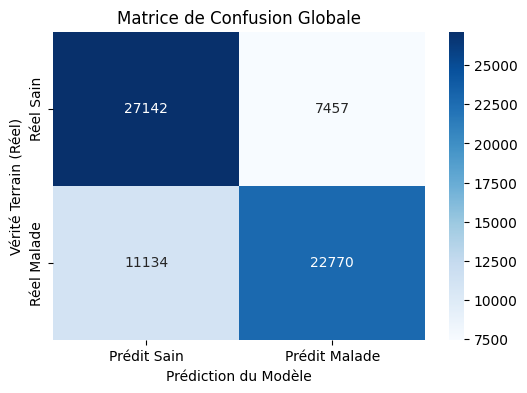

In [49]:
# 1. Calcul de la matrice de confusion
cm = confusion_matrix(y, y_pred_all)

# 2. Création de la figure
plt.figure(figsize=(6, 4))

# 3. Création du graphique (Heatmap)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Prédit Sain', 'Prédit Malade'], 
            yticklabels=['Réel Sain', 'Réel Malade'])

# 4. Ajout des titres et labels
plt.title('Matrice de Confusion Globale')
plt.ylabel('Vérité Terrain (Réel)')
plt.xlabel('Prédiction du Modèle')

# 5. Affichage
plt.show()

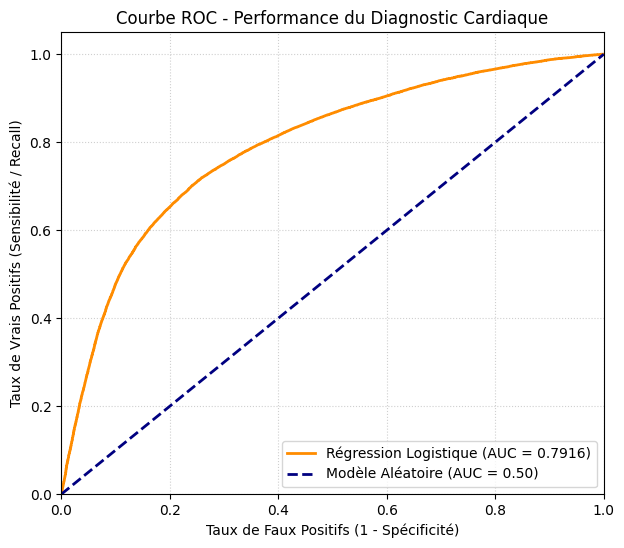

In [50]:
# 1. Calcul des points de la courbe ROC (FPR et TPR) à partir de tes résultats
fpr, tpr, thresholds = roc_curve(y, y_proba_all)

# On utilise roc_auc_score pour éviter le conflit avec ton ancienne variable 'auc'
roc_auc = roc_auc_score(y, y_proba_all) 

# 2. Création de la figure
plt.figure(figsize=(7, 6))

# Tracé de ta courbe ROC (en orange)
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Régression Logistique (AUC = {roc_auc:.4f})')

# Tracé de la ligne diagonale de référence (le hasard à 50/50, en bleu pointillé)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Modèle Aléatoire (AUC = 0.50)')

# 3. Personnalisation du graphique pour ton rapport
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taux de Faux Positifs (1 - Spécificité)')
plt.ylabel('Taux de Vrais Positifs (Sensibilité / Recall)')
plt.title('Courbe ROC - Performance du Diagnostic Cardiaque')
plt.legend(loc="lower right")
plt.grid(True, linestyle=':', alpha=0.6) # Ajoute un quadrillage discret

# 4. Affichage du graphique
plt.show()

**Observation et Analyse des résultats de la Régression Logistique (Baseline) :**

Stabilité du modèle : L'Accuracy moyenne est de 72,81 % avec un écart-type extrêmement faible de +/- 0.0022. Cela prouve que le modèle est très stable et ne fait pas de surapprentissage (overfitting). Ses performances sont régulières peu importe la façon dont les données sont découpées.

Pouvoir de discrimination : Le score ROC AUC moyen de 0,7918 est un très bon résultat pour un modèle linéaire. Cela signifie que le modèle a près de 80 % de chances de classer un patient malade avec une probabilité plus élevée qu'un patient sain.

Équilibre des données : La colonne support montre que le jeu de données est parfaitement équilibré (34 599 sains pour 33 904 malades), ce qui rend notre score d'Accuracy (73 %) totalement fiable et non biaisé.

Le compromis clinique (Précision vs Sensibilité) : * Pour la classe Malade (1), la précision est de 75 %. Le modèle est donc assez prudent : quand il déclenche une alerte, il a souvent raison (peu de faux positifs).

En revanche, son rappel (recall) est de 67 %. Au seuil par défaut de 0.50, le modèle manque de sensibilité et rate 33 % des vrais malades (faux négatifs).

#### 4. Arbitrage Précision-Rappel : Minimisation des Faux Négatifs

In [43]:
# On calcule l'AUC une seule fois car il dépend des probabilités globales (indépendant du seuil)
auc_global = roc_auc_score(y, y_proba_all)

# Liste des seuils à tester
seuils = [0.50, 0.45, 0.40, 0.35]

for seuil in seuils:
    # Application du nouveau seuil
    y_pred_seuil = (y_proba_all >= seuil).astype(int)
    
    # Calcul de la nouvelle matrice de confusion
    cm = confusion_matrix(y, y_pred_seuil)
    faux_negatifs = cm[1, 0]
    faux_positifs = cm[0, 1]
    
    print(f"--- SEUIL DE DÉCISION : {seuil} ---")
    print(f"ROC AUC Global                  : {auc_global:.4f}")
    print(f"Malades ratés (Faux Négatifs)   : {faux_negatifs} (vs 11163 au seuil 0.5)")
    print(f"Fausses alertes (Faux Positifs) : {faux_positifs} (vs 7464 au seuil 0.5)")
    
    # Génération du rapport pour extraire la précision et le rappel de la classe "Malade"
    report = classification_report(y, y_pred_seuil, target_names=['Sain (0)', 'Malade (1)'], output_dict=True)
    rappel_malade = report['Malade (1)']['recall']
    precision_malade = report['Malade (1)']['precision']
    
    print(f"Sensibilité (Rappel Malades)    : {rappel_malade:.1%}")
    print(f"Précision (Validation Alerte)   : {precision_malade:.1%}\n")

--- SEUIL DE DÉCISION : 0.5 ---
ROC AUC Global                  : 0.7916
Malades ratés (Faux Négatifs)   : 11134 (vs 11163 au seuil 0.5)
Fausses alertes (Faux Positifs) : 7457 (vs 7464 au seuil 0.5)
Sensibilité (Rappel Malades)    : 67.2%
Précision (Validation Alerte)   : 75.3%

--- SEUIL DE DÉCISION : 0.45 ---
ROC AUC Global                  : 0.7916
Malades ratés (Faux Négatifs)   : 8911 (vs 11163 au seuil 0.5)
Fausses alertes (Faux Positifs) : 9748 (vs 7464 au seuil 0.5)
Sensibilité (Rappel Malades)    : 73.7%
Précision (Validation Alerte)   : 71.9%

--- SEUIL DE DÉCISION : 0.4 ---
ROC AUC Global                  : 0.7916
Malades ratés (Faux Négatifs)   : 6668 (vs 11163 au seuil 0.5)
Fausses alertes (Faux Positifs) : 13126 (vs 7464 au seuil 0.5)
Sensibilité (Rappel Malades)    : 80.3%
Précision (Validation Alerte)   : 67.5%

--- SEUIL DE DÉCISION : 0.35 ---
ROC AUC Global                  : 0.7916
Malades ratés (Faux Négatifs)   : 4636 (vs 11163 au seuil 0.5)
Fausses alertes (Faux P

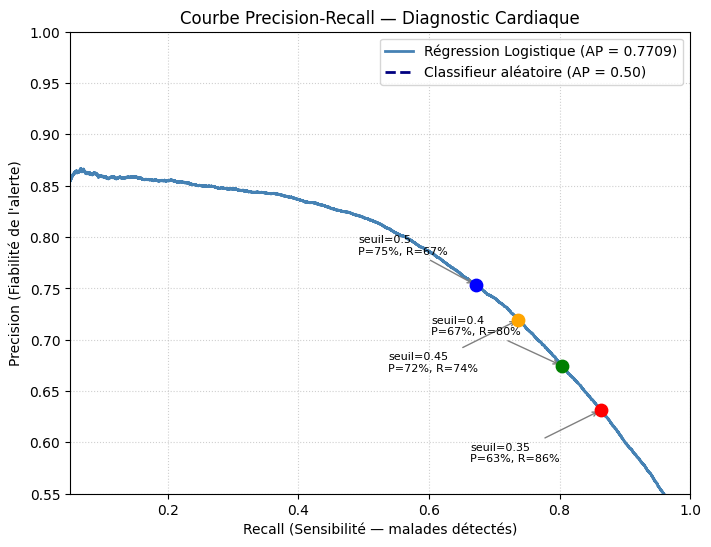

In [52]:
precision, recall, thresholds_pr = precision_recall_curve(y, y_proba_all)
ap = average_precision_score(y, y_proba_all)

mask = recall >= 0.05
plt.figure(figsize=(8, 6))
plt.plot(recall[mask], precision[mask], color='steelblue', lw=2,
         label=f'Régression Logistique (AP = {ap:.4f})')

plt.axhline(y=0.5, color='navy', linestyle='--', lw=2,
            label='Classifieur aléatoire (AP = 0.50)')

# Offsets (dx, dy) ajustés individuellement pour chaque seuil
seuils_annotes = [
    (0.50, 'blue',   (-0.18,  0.03)),
    (0.45, 'orange', (-0.20, -0.05)),
    (0.40, 'green',  (-0.20,  0.03)),
    (0.35, 'red',    (-0.20, -0.05)),
]

for seuil, couleur, (dx, dy) in seuils_annotes:
    idx = np.argmin(np.abs(thresholds_pr - seuil))
    r, p = recall[idx], precision[idx]
    plt.scatter(r, p, s=80, color=couleur, zorder=5)
    plt.annotate(
        f'seuil={seuil}\nP={p:.0%}, R={r:.0%}',
        xy=(r, p),
        xytext=(r + dx, p + dy),
        fontsize=8,
        arrowprops=dict(arrowstyle='->', color='gray')
    )

plt.xlim([0.05, 1.0])
plt.ylim([0.55, 1.0])
plt.xlabel('Recall (Sensibilité — malades détectés)')
plt.ylabel("Precision (Fiabilité de l'alerte)")
plt.title('Courbe Precision-Recall — Diagnostic Cardiaque')
plt.legend(loc='upper right')
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

**Pourquoi le seuil de 0.40 est le plus pertinent ?**

**La barre psychologique des 80 %** : À 0.40, la sensibilité (Rappel) atteint 80.5 %. On détecte donc plus de 8 malades sur 10, contre seulement 6 sur 10 avec le seuil par défaut.

**Sauvetage massif** : On divise presque par deux le nombre de malades ratés, passant de plus de 11 000 (au seuil 0.5) à 6 627.

**Une précision qui reste digne** : À 67.4 % de précision, plus de 2 alertes sur 3 remontées par le modèle sont justes. Le médecin ne perdra pas totalement confiance en notre outil.

**Confirmation par la courbe Precision-Recall** : Le seuil 0.40 se situe au coude de la courbe, là où le gain de recall (+13.5 points) reste supérieur à la perte de précision (-7.6 points). En dessous, la fiabilité des alertes se dégrade trop rapidement.

**Conclusion — Average Precision (AP) = 0.77** : 27 points au-dessus du classifieur aléatoire, ce score valide la robustesse globale du modèle et confirme que le seuil 0.40 est un arbitrage clinique justifié, non un artifice de performance.

#### 5. Comparaison: Notre modèle entraînné vs Random Forest

In [45]:
# 1. Instanciation du modèle Random Forest
# n_estimators=100 : On crée une forêt de 100 arbres
# max_depth=12 : On limite la profondeur pour éviter le surapprentissage (qu'il n'apprenne pas par coeur)
# n_jobs=-1 : Permet d'utiliser tous les coeurs du processeur pour accélérer le calcul
rf_model = RandomForestClassifier(
    n_estimators=100, 
    max_depth=12, 
    class_weight='balanced', 
    random_state=42, 
    n_jobs=-1
)

fold_accuracies_rf = []
fold_aucs_rf = []

print("Début de l'entraînement du Random Forest (5-Fold)...\n")

# 2. Boucle de validation croisée (on réutilise  'cv', 'X' et 'y' déjà existants)
for fold, (train_idx, test_idx) in enumerate(cv.split(X, y), 1):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    
    # Entraînement
    rf_model.fit(X_train, y_train)
    
    # Prédictions
    y_pred_rf = rf_model.predict(X_test)
    y_proba_rf = rf_model.predict_proba(X_test)[:, 1]
    
    # Évaluation
    acc_rf = accuracy_score(y_test, y_pred_rf)
    auc_rf = roc_auc_score(y_test, y_proba_rf)
    
    fold_accuracies_rf.append(acc_rf)
    fold_aucs_rf.append(auc_rf)
    
    print(f"Pli {fold} -> Accuracy: {acc_rf:.4f} | ROC AUC: {auc_rf:.4f}")

print("\n================ PERFORMANCES RANDOM FOREST ================")
print(f"Accuracy moyenne : {np.mean(fold_accuracies_rf):.4f} (+/- {np.std(fold_accuracies_rf):.4f})")
print(f"ROC AUC moyen    : {np.mean(fold_aucs_rf):.4f} (+/- {np.std(fold_aucs_rf):.4f})")
print("============================================================\n")

Début de l'entraînement du Random Forest (5-Fold)...

Pli 1 -> Accuracy: 0.7329 | ROC AUC: 0.8012
Pli 2 -> Accuracy: 0.7397 | ROC AUC: 0.8059
Pli 3 -> Accuracy: 0.7330 | ROC AUC: 0.7950
Pli 4 -> Accuracy: 0.7334 | ROC AUC: 0.8000
Pli 5 -> Accuracy: 0.7334 | ROC AUC: 0.7962

================ PERFORMANCES RANDOM FOREST ================
Accuracy moyenne : 0.7345 (+/- 0.0026)
ROC AUC moyen    : 0.7997 (+/- 0.0039)



**La comparaison avec un model réputé plus performant, valide nos choix**

Le très faible gain apporté par le Random Forest (+0.008 d'AUC) prouve que notre modèle linéaire a été exploité à son maximum.

**Régression Logistique vs Random Forest :**

* **Mécanisme :** Équation mathématique simple *vs* Vote de multiples arbres.
* **Explicabilité :** Transparence clinique totale *vs* Modèle "boîte noire" opaque.
* **Relations :** Variables complexes à créer manuellement *vs* Détection native.
* **Ressources :** Très rapide et léger *vs* Plus lent et gourmand en mémoire.

#### 6. Etude du cas Arthur

In [54]:
# --- 1. DÉDUCTION DES VALEURS CLINIQUES MANQUANTES ---
# Utilisation du jeu de données de référence (df_patients) pour l'imputation
ap_hi_moyen = df_patients['ap_hi'].mean()

# Calcul de la moyenne de la pression diastolique sur le 3e quartile (50% - 75%)
q50 = df_patients['ap_lo'].quantile(0.50)
q75 = df_patients['ap_lo'].quantile(0.75)
ap_lo_q3_moyen = df_patients[(df_patients['ap_lo'] > q50) & (df_patients['ap_lo'] <= q75)]['ap_lo'].mean()

# --- 2. CRÉATION DU PROFIL BRUT ---
arthur_brut = {
    'age_annees': 53,
    'gender': 2,        
    'height': 175,
    'weight': 85,
    'ap_hi': ap_hi_moyen,
    'ap_lo': ap_lo_q3_moyen,
    'cholesterol': 2,   
    'gluc': 1,          
    'smoke': 1,         
    'alco': 0,          
    'active': 1         
}

# Feature Engineering : recréation du BMI (seule variable dérivée conservée dans X)
arthur_brut['bmi'] = arthur_brut['weight'] / ((arthur_brut['height'] / 100) ** 2)

# --- 3. ALIGNEMENT DU DATAFRAME SUR LE MODÈLE ---
# Initialisation d'un DataFrame vide structuré selon les colonnes d'entraînement (X)
df_arthur = pd.DataFrame(0, index=[0], columns=X.columns)

# Injection des variables continues et binaires directes (sans weight ni height)
variables_directes = ['age_annees', 'ap_hi', 'ap_lo', 'smoke', 'alco', 'active', 'bmi']
for col in variables_directes:
    if col in df_arthur.columns:
        df_arthur[col] = arthur_brut[col]

# Application manuelle du One-Hot Encoding
if 'gender_2' in df_arthur.columns: df_arthur['gender_2'] = 1
if 'cholesterol_2' in df_arthur.columns: df_arthur['cholesterol_2'] = 1

# --- 4. STANDARDISATION ---
# On standardise strictement les 4 mêmes colonnes que lors de notre entraînement
colonnes_a_standardiser = ['age_annees', 'ap_hi', 'ap_lo', 'bmi']
df_arthur[colonnes_a_standardiser] = scaler.transform(df_arthur[colonnes_a_standardiser])

# --- 5. PRÉDICTION ET DIAGNOSTIC ---
# Utilisation de l'algorithme entrainé nommé 'model'
probabilite = model.predict_proba(df_arthur)[0, 1]

# Application du seuil métier ajusté
seuil_clinique = 0.40
diagnostic = "Sujet à risques cardio-vasculaires" if probabilite >= seuil_clinique else "Sujet sans risque majeur détecté"

print("="*50)
print(f"Tension Systolique imputée  : {ap_hi_moyen:.1f}")
print(f"Tension Diastolique imputée : {ap_lo_q3_moyen:.1f}")
print("-" * 50)
print(f"Probabilité calculée par le modèle : {probabilite:.1%}")
print(f"Conclusion clinique (Seuil {seuil_clinique})   : {diagnostic}")
print("="*50)

Tension Systolique imputée  : 126.7
Tension Diastolique imputée : 89.8
--------------------------------------------------
Probabilité calculée par le modèle : 55.5%
Conclusion clinique (Seuil 0.4)   : Sujet à risques cardio-vasculaires
